# Domain A: Transcriptomic Identity and Neural Coding

This notebook addresses three questions:
- **A1:** Do transcriptomically defined cell types have distinct tuning properties?
- **A2:** Does gene expression predict functional response properties at the single-cell level?
- **A3:** How does transcriptomic identity shape population coding geometry?

**Data:** Zarr multimodal stores with ΔF/F calcium traces (X matrix, cells × trials), stimulus metadata (var), cell-type labels & gene expression (obs).

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
from types import SimpleNamespace
from scipy.optimize import curve_fit
from scipy.stats import kruskal, mannwhitneyu, spearmanr, pearsonr
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.decomposition import PCA, NMF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.manifold import TSNE
from pathlib import Path    
from matplotlib import cm, colors
import warnings
import anndata as ad
warnings.filterwarnings('ignore')

from functions.data_loading import load_mouse_zarr, zarr_to_df
from functions.visualization import polar_bar_plot

sns.set_context('talk')
sns.set_style('whitegrid')

# ══════════════════════════════════════════════════════════════════════
# Load data from zarr multimodal stores
# ══════════════════════════════════════════════════════════════════════
MULTIMODAL = Path('../scratch/multimodal_data')
MOUSE_IDS = [f.stem.split('_')[0] for f in MULTIMODAL.glob('*_multimodal_data.zarr')]
SESSIONS = ['session_1', 'session_2', 'session_3']
session_type = ['drifting_gratings']
MOUSE_IDS

[]

In [2]:
obs = [adata.obs for adata in adata_list]
obs = pd.concat(obs, ignore_index=True)
# ── Identify gene expression columns ──
META_COLS = {'unique_id', 'mouse_id', 'class_name', 'class_label',
             'class_bootstrapping_probability', 'subclass_name', 'subclass_label',
             'subclass_bootstrapping_probability', 'supertype_name', 'supertype_label',
             'supertype_bootstrapping_probability', 'cluster_name', 'cluster_label',
             'cluster_alias', 'cluster_bootstrapping_probability',
             'x_loc', 'y_loc', 'z_loc'}
GENE_COLS = [c for c in obs.columns if c not in META_COLS]
print(f"Gene expression columns: {len(GENE_COLS)}")

# ── Color palette for subclasses ──
SUBCLASS_ORDER = ['007 L2/3 IT CTX Glut', '006 L4/5 IT CTX Glut', '022 L5 ET CTX Glut',
                  '052 Pvalb Gaba', '053 Sst Gaba', '046 Vip Gaba', '049 Lamp5 Gaba']
SUBCLASS_COLORS = {'007 L2/3 IT CTX Glut': '#1f77b4', '006 L4/5 IT CTX Glut': '#2ca02c',
                   '022 L5 ET CTX Glut': '#9467bd', '052 Pvalb Gaba': '#d62728',
                   '053 Sst Gaba': '#ff7f0e', '046 Vip Gaba': '#e377c2', '049 Lamp5 Gaba': '#8c564b'}
SUBCLASS_SHORT = {'007 L2/3 IT CTX Glut': 'L2/3 IT', '006 L4/5 IT CTX Glut': 'L4/5 IT',
                  '022 L5 ET CTX Glut': 'L5 ET', '052 Pvalb Gaba': 'Pvalb',
                  '053 Sst Gaba': 'Sst', '046 Vip Gaba': 'Vip', '049 Lamp5 Gaba': 'Lamp5'}
present_subclasses = [s for s in SUBCLASS_ORDER if s in obs['subclass_name'].unique()]

orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
contrasts = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
tfs = np.array([1, 2, 4, 8, 15])


NameError: name 'adata_list' is not defined

## A2: Gene Expression Predicts Functional Response Properties

Correlate each gene's expression with tuning metrics, run LASSO regression, and identify co-expression modules.

Total gene-metric pairs tested: 1485
Significant (FDR<0.05): 197


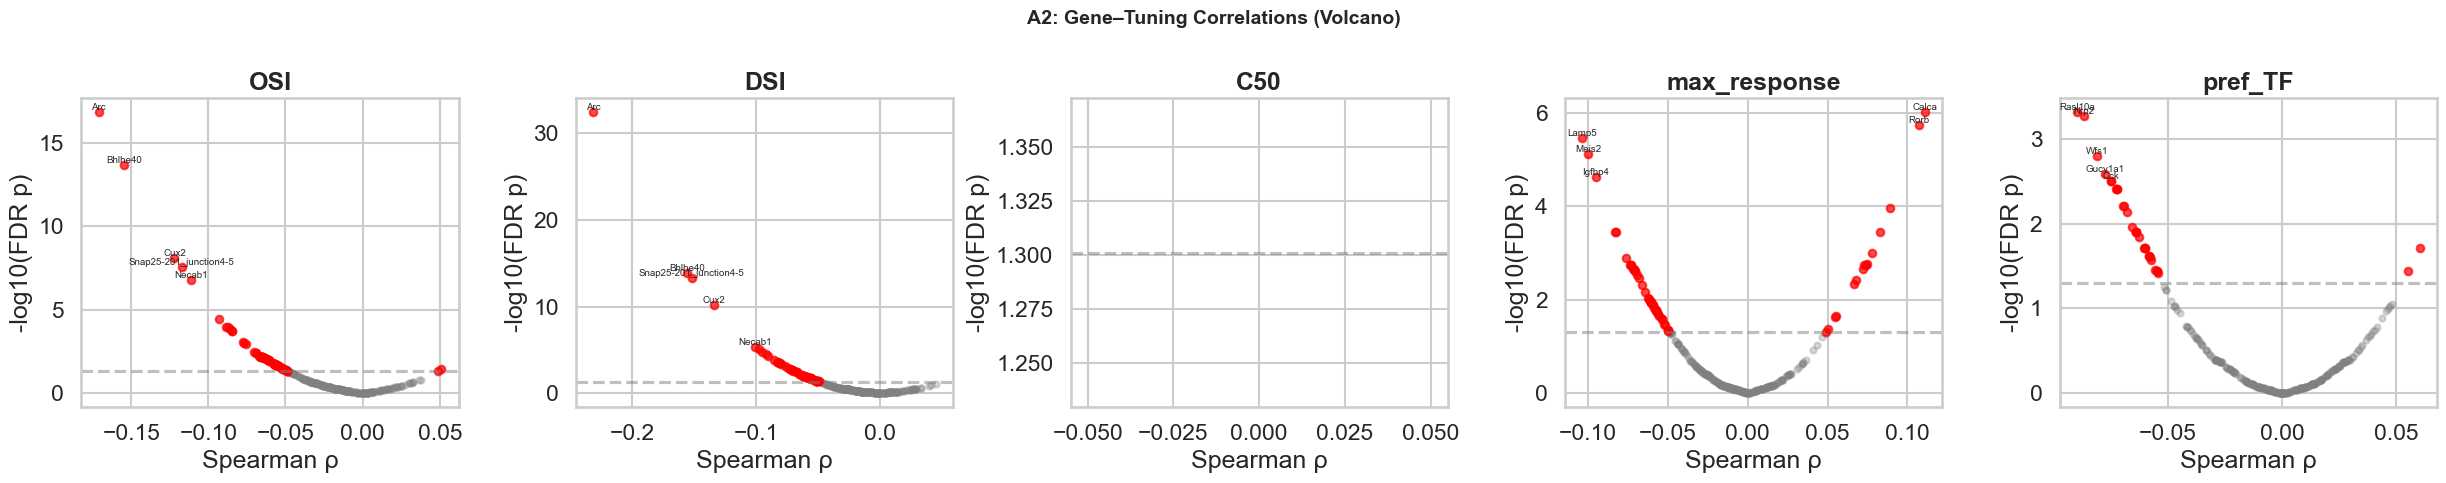


Within-subclass correlations computed: 3552
subclass  metric      
L2/3 IT   OSI             67
          max_response    13
L4/5 IT   OSI             68
          max_response    39
L5 ET     OSI              4
          max_response     5
Lamp5     OSI              4
          max_response     5
Pvalb     OSI             34
          max_response    13
Sst       OSI              2
          max_response    16
Vip       OSI              7
          max_response     8
dtype: int64


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A2.1  Gene–Tuning Spearman Correlations (whole population + within-subclass)
# ══════════════════════════════════════════════════════════════════════
from statsmodels.stats.multitest import multipletests

gene_expr = obs[GENE_COLS].values.astype(float)  # n_cells x n_genes
target_metrics = ['OSI', 'DSI', 'C50', 'max_response', 'pref_TF']

# ── Whole-population correlations ──
corr_results = []
for gi, gene in enumerate(GENE_COLS):
    gx = gene_expr[:, gi]
    if np.std(gx) < 1e-6:
        continue
    for met in target_metrics:
        y = tuning_df[met].values
        valid = ~np.isnan(y) & ~np.isnan(gx)
        if valid.sum() < 20:
            continue
        rho, p = spearmanr(gx[valid], y[valid])
        corr_results.append({'gene': gene, 'metric': met, 'rho': rho, 'p': p})

corr_df = pd.DataFrame(corr_results)
# FDR correction per metric
for met in target_metrics:
    mask = corr_df['metric'] == met
    if mask.sum() > 0:
        _, pvals_adj, _, _ = multipletests(corr_df.loc[mask, 'p'], method='fdr_bh')
        corr_df.loc[mask, 'p_adj'] = pvals_adj

corr_df['sig'] = corr_df['p_adj'] < 0.05
print(f"Total gene-metric pairs tested: {len(corr_df)}")
print(f"Significant (FDR<0.05): {corr_df['sig'].sum()}")

# ── Volcano plot for each metric ──
fig, axes = plt.subplots(1, len(target_metrics), figsize=(5*len(target_metrics), 5))
for ax, met in zip(axes, target_metrics):
    sub = corr_df[corr_df['metric'] == met].copy()
    sub['-log10p'] = -np.log10(sub['p_adj'].clip(1e-50))
    ax.scatter(sub.loc[~sub['sig'], 'rho'], sub.loc[~sub['sig'], '-log10p'],
               alpha=0.3, s=20, c='gray')
    ax.scatter(sub.loc[sub['sig'], 'rho'], sub.loc[sub['sig'], '-log10p'],
               alpha=0.7, s=30, c='red')
    # Label top genes
    top = sub.nlargest(5, '-log10p')
    for _, row in top.iterrows():
        ax.annotate(row['gene'], (row['rho'], row['-log10p']), fontsize=7,
                   ha='center', va='bottom')
    ax.axhline(-np.log10(0.05), ls='--', color='gray', alpha=0.5)
    ax.set_xlabel('Spearman ρ')
    ax.set_ylabel('-log10(FDR p)')
    ax.set_title(met, fontweight='bold')
plt.suptitle('A2: Gene–Tuning Correlations (Volcano)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Within-subclass correlations (control for cell-type effects) ──
within_corr = []
for sc in present_subclasses:
    sc_mask = obs['subclass_name'].values == sc
    if sc_mask.sum() < 20:
        continue
    for gi, gene in enumerate(GENE_COLS):
        gx = gene_expr[sc_mask, gi]
        if np.std(gx) < 1e-6:
            continue
        for met in ['OSI', 'max_response']:
            y = tuning_df.loc[sc_mask, met].values
            valid = ~np.isnan(y) & ~np.isnan(gx)
            if valid.sum() < 10:
                continue
            rho, p = spearmanr(gx[valid], y[valid])
            within_corr.append({'subclass': SUBCLASS_SHORT[sc], 'gene': gene, 'metric': met, 'rho': rho, 'p': p})

within_df = pd.DataFrame(within_corr)
print(f"\nWithin-subclass correlations computed: {len(within_df)}")
print(within_df.groupby(['subclass', 'metric']).apply(lambda x: (x['p'] < 0.05).sum()).head(20))

Genes with non-zero variance: 297

OSI: R²(CV) = -0.618, r = -0.287
  Top predictive genes: [(np.str_('EGFP'), '0.009'), (np.str_('Bhlhe40'), '-0.008'), (np.str_('Lamp5'), '0.006'), (np.str_('Arc'), '-0.005'), (np.str_('Snap25-201_junction4-5'), '-0.004'), (np.str_('Cux2'), '-0.004'), (np.str_('Bdnf'), '0.004'), (np.str_('SYFP2'), '-0.003')]

DSI: R²(CV) = -0.583, r = -0.427
  Top predictive genes: [(np.str_('Arc'), '-0.005'), (np.str_('EGFP'), '0.005'), (np.str_('Snap25-201_junction4-5'), '-0.003'), (np.str_('Pde7b'), '0.002'), (np.str_('Bhlhe40'), '-0.002'), (np.str_('Slc17a6'), '0.002'), (np.str_('Bdnf'), '0.002'), (np.str_('Rln1'), '0.001')]

C50: R²(CV) = -0.007, r = -0.066
  Top predictive genes: []

max_response: R²(CV) = -0.053, r = -0.198
  Top predictive genes: [(np.str_('Arc'), '-0.003'), (np.str_('Gfra2'), '0.001'), (np.str_('Rorb'), '0.001'), (np.str_('EGFP'), '0.001'), (np.str_('Meis2'), '-0.001'), (np.str_('Tac2'), '0.000'), (np.str_('Cyp1b1'), '0.000'), (np.str_('Sla'),

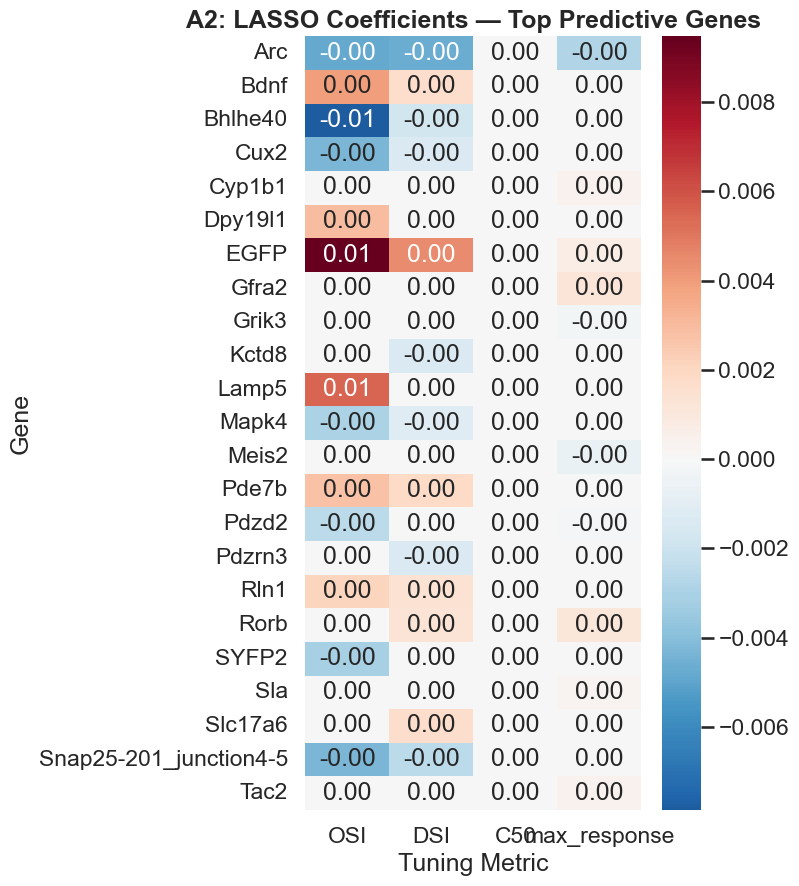

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A2.2  LASSO / Elastic-Net: predict tuning from gene expression
# ══════════════════════════════════════════════════════════════════════

gene_matrix = obs[GENE_COLS].values.astype(float)
# Impute NaNs with zero (most genes are zero for many cells)
gene_matrix = np.nan_to_num(gene_matrix, nan=0.0)
# Remove zero-variance genes
nonzero_var = np.std(gene_matrix, axis=0) > 1e-6
gene_matrix_filt = gene_matrix[:, nonzero_var]
gene_names_filt = np.array(GENE_COLS)[nonzero_var]
print(f"Genes with non-zero variance: {gene_matrix_filt.shape[1]}")

scaler_g = StandardScaler()
gene_scaled = scaler_g.fit_transform(gene_matrix_filt)
mouse_ids_all = obs['mouse_id'].values

lasso_results = {}
for met in ['OSI', 'DSI', 'C50', 'max_response']:
    y = tuning_df[met].values
    valid = ~np.isnan(y)
    X_g = gene_scaled[valid]
    y_g = y[valid]
    mice = mouse_ids_all[valid]

    # Leave-one-mouse-out cross-validation
    logo = LeaveOneGroupOut()
    y_pred_cv = np.full_like(y_g, np.nan)
    coefs = []
    for train_idx, test_idx in logo.split(X_g, y_g, groups=mice):
        lasso = LassoCV(cv=5, max_iter=5000, n_alphas=50)
        lasso.fit(X_g[train_idx], y_g[train_idx])
        y_pred_cv[test_idx] = lasso.predict(X_g[test_idx])
        coefs.append(lasso.coef_)

    valid_pred = ~np.isnan(y_pred_cv)
    r2 = 1 - np.sum((y_g[valid_pred] - y_pred_cv[valid_pred])**2) / np.sum((y_g[valid_pred] - np.mean(y_g[valid_pred]))**2)
    rho_cv, _ = pearsonr(y_g[valid_pred], y_pred_cv[valid_pred])

    # Average coefficients across folds
    mean_coef = np.mean(coefs, axis=0)
    top_genes_idx = np.argsort(np.abs(mean_coef))[::-1][:15]
    top_genes = [(gene_names_filt[i], mean_coef[i]) for i in top_genes_idx if abs(mean_coef[i]) > 1e-6]

    lasso_results[met] = {'r2': r2, 'r': rho_cv, 'top_genes': top_genes}
    print(f"\n{met}: R²(CV) = {r2:.3f}, r = {rho_cv:.3f}")
    print(f"  Top predictive genes: {[(g, f'{c:.3f}') for g, c in top_genes[:8]]}")

# ── Visualization: Top genes heatmap ──
all_top_genes = set()
for met, res in lasso_results.items():
    for g, c in res['top_genes'][:10]:
        all_top_genes.add(g)
all_top_genes = sorted(all_top_genes)

if len(all_top_genes) > 0:
    heatmap_data = pd.DataFrame(0.0, index=all_top_genes, columns=list(lasso_results.keys()))
    for met, res in lasso_results.items():
        for g, c in res['top_genes']:
            if g in all_top_genes:
                heatmap_data.loc[g, met] = c

    fig, ax = plt.subplots(figsize=(8, max(6, len(all_top_genes)*0.4)))
    sns.heatmap(heatmap_data, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
    ax.set_title('A2: LASSO Coefficients — Top Predictive Genes', fontweight='bold')
    ax.set_xlabel('Tuning Metric')
    ax.set_ylabel('Gene')
    plt.tight_layout()
    plt.show()

NMF decomposition: 2824 cells × 8 modules
  Module 0: EGFP, SYFP2, Cck, Dkk3, Rims3
  Module 1: Gad1, Pvalb, Pcp4l1, Dner, Rab3b
  Module 2: Nrn1, Rorb, Cre, Slc17a7, Kcnh5
  Module 3: Nrn1, Slc17a7, Cck, Wfs1, Cux2
  Module 4: Gad1, Npy, Dner, Gad2, Vip
  Module 5: SYFP2, EGFP, Nrn1, Lamp5, Epha4
  Module 6: Arc, Nrn1, Bhlhe40, Rims3, Dkk3
  Module 7: Lamp5, Nrn1, Calb1, Rasgrf2, Bhlhe40


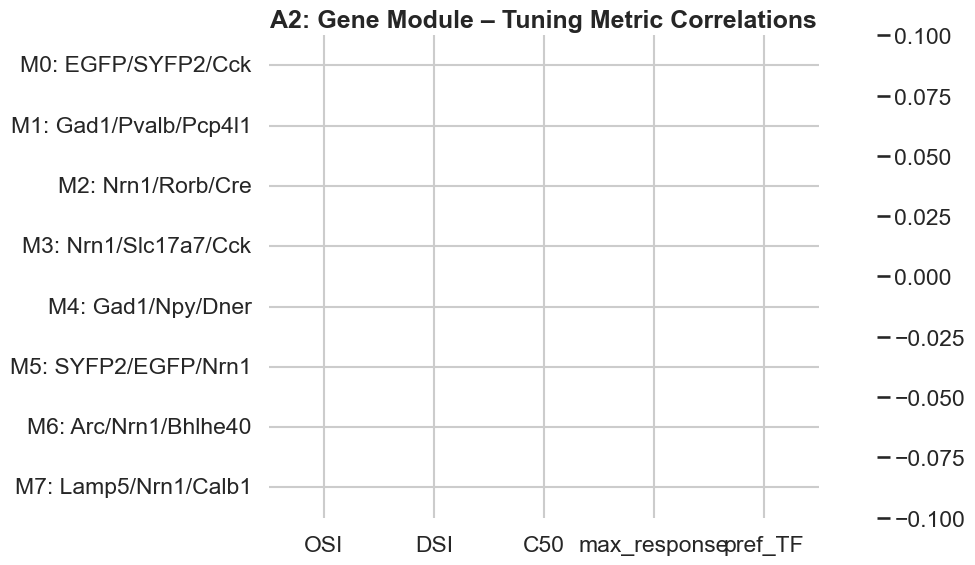

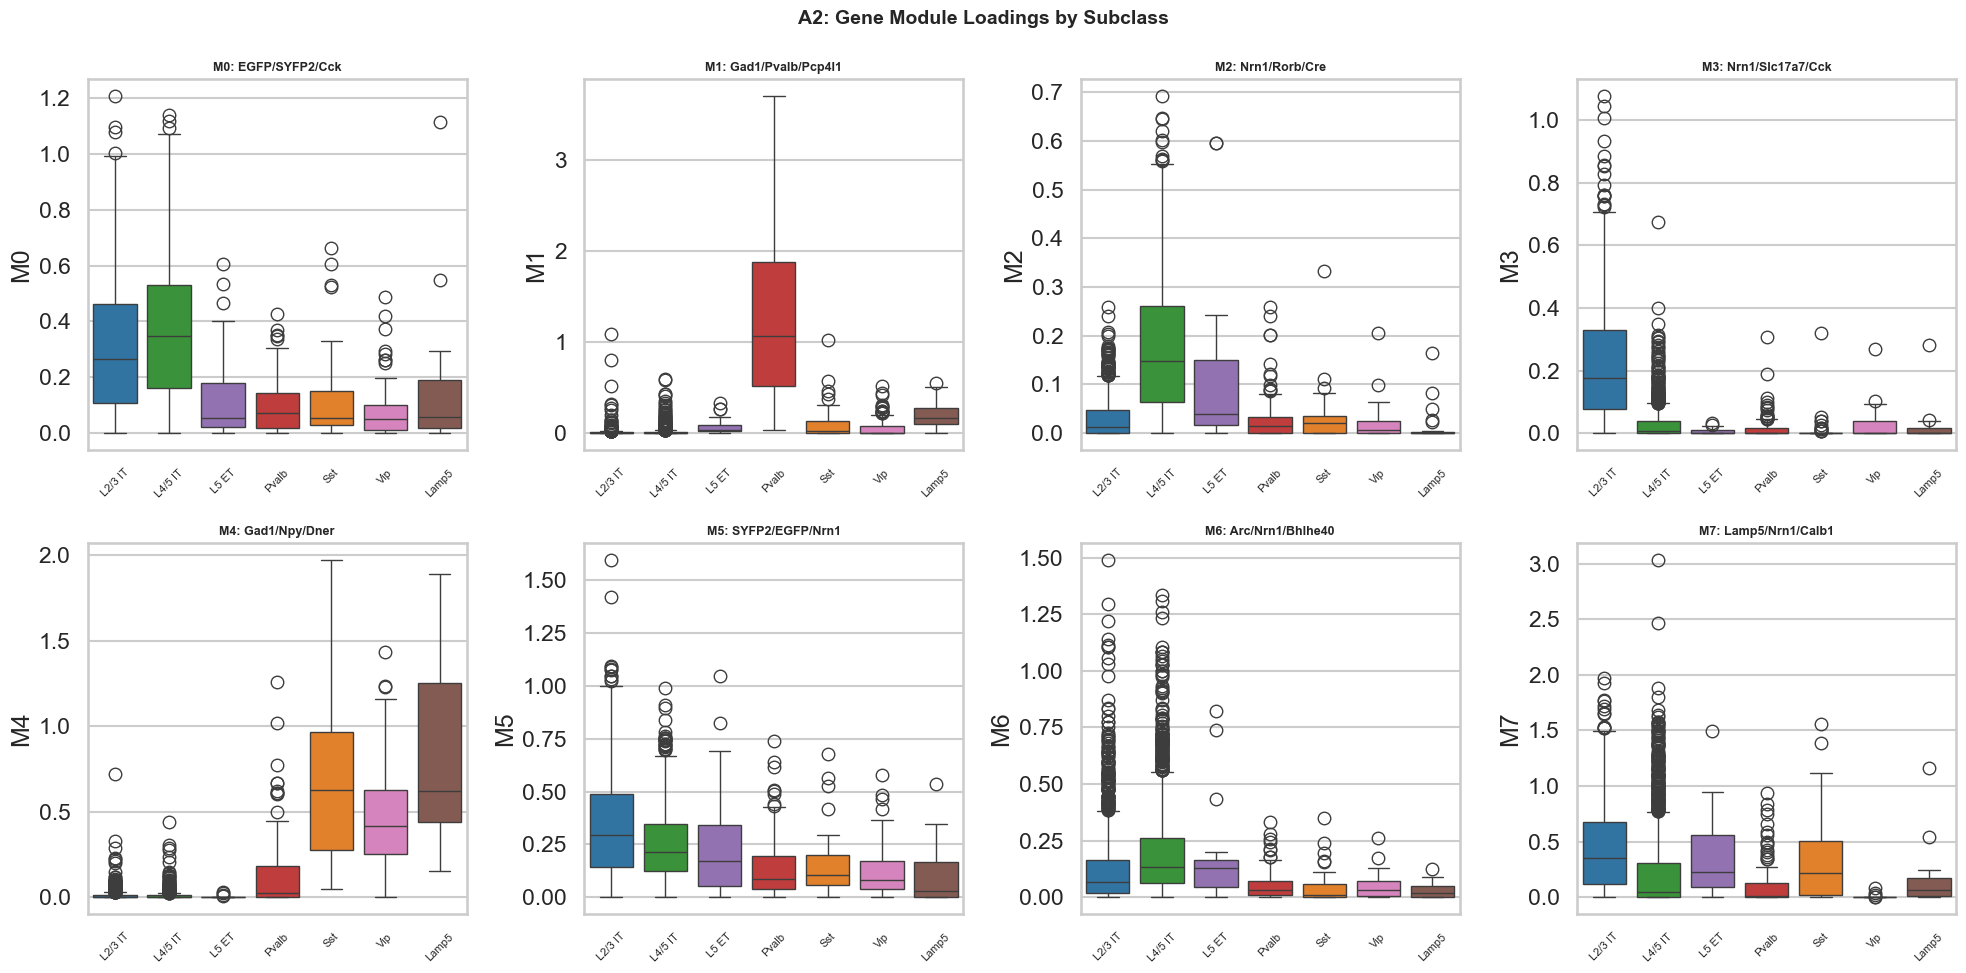

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A2.3  Gene co-expression modules (NMF) and their functional associations
# ══════════════════════════════════════════════════════════════════════

# NMF on gene expression matrix (non-negative)
gene_matrix_nn = np.maximum(gene_matrix_filt, 0)
n_modules = 8

nmf = NMF(n_components=n_modules, max_iter=500, random_state=42)
W = nmf.fit_transform(gene_matrix_nn)  # cells x modules
H = nmf.components_  # modules x genes

print(f"NMF decomposition: {W.shape[0]} cells × {n_modules} modules")

# Name modules by top genes
module_names = []
for m in range(n_modules):
    top_idx = np.argsort(H[m])[::-1][:5]
    top = [gene_names_filt[i] for i in top_idx]
    module_names.append(f"M{m}: {'/'.join(top[:3])}")
    print(f"  Module {m}: {', '.join(top)}")

# ── Correlate modules with tuning metrics ──
module_tuning_corr = pd.DataFrame(index=module_names, columns=target_metrics, dtype=float)
for m in range(n_modules):
    for met in target_metrics:
        y = tuning_df[met].values
        valid = ~np.isnan(y)
        rho, p = spearmanr(W[valid, m], y[valid])
        module_tuning_corr.iloc[m][met] = rho

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(module_tuning_corr.astype(float), cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('A2: Gene Module – Tuning Metric Correlations', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Module loading by subclass ──
module_by_subclass = pd.DataFrame(W, columns=[f'M{i}' for i in range(n_modules)])
module_by_subclass['subclass'] = obs['subclass_name'].values
module_by_subclass['subclass_short'] = module_by_subclass['subclass'].map(SUBCLASS_SHORT)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, m in zip(axes.flat, range(n_modules)):
    sns.boxplot(data=module_by_subclass, x='subclass_short', y=f'M{m}',
                order=[SUBCLASS_SHORT[s] for s in present_subclasses],
                palette={SUBCLASS_SHORT[k]: v for k, v in SUBCLASS_COLORS.items()}, ax=ax)
    ax.set_title(module_names[m], fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.suptitle('A2: Gene Module Loadings by Subclass', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

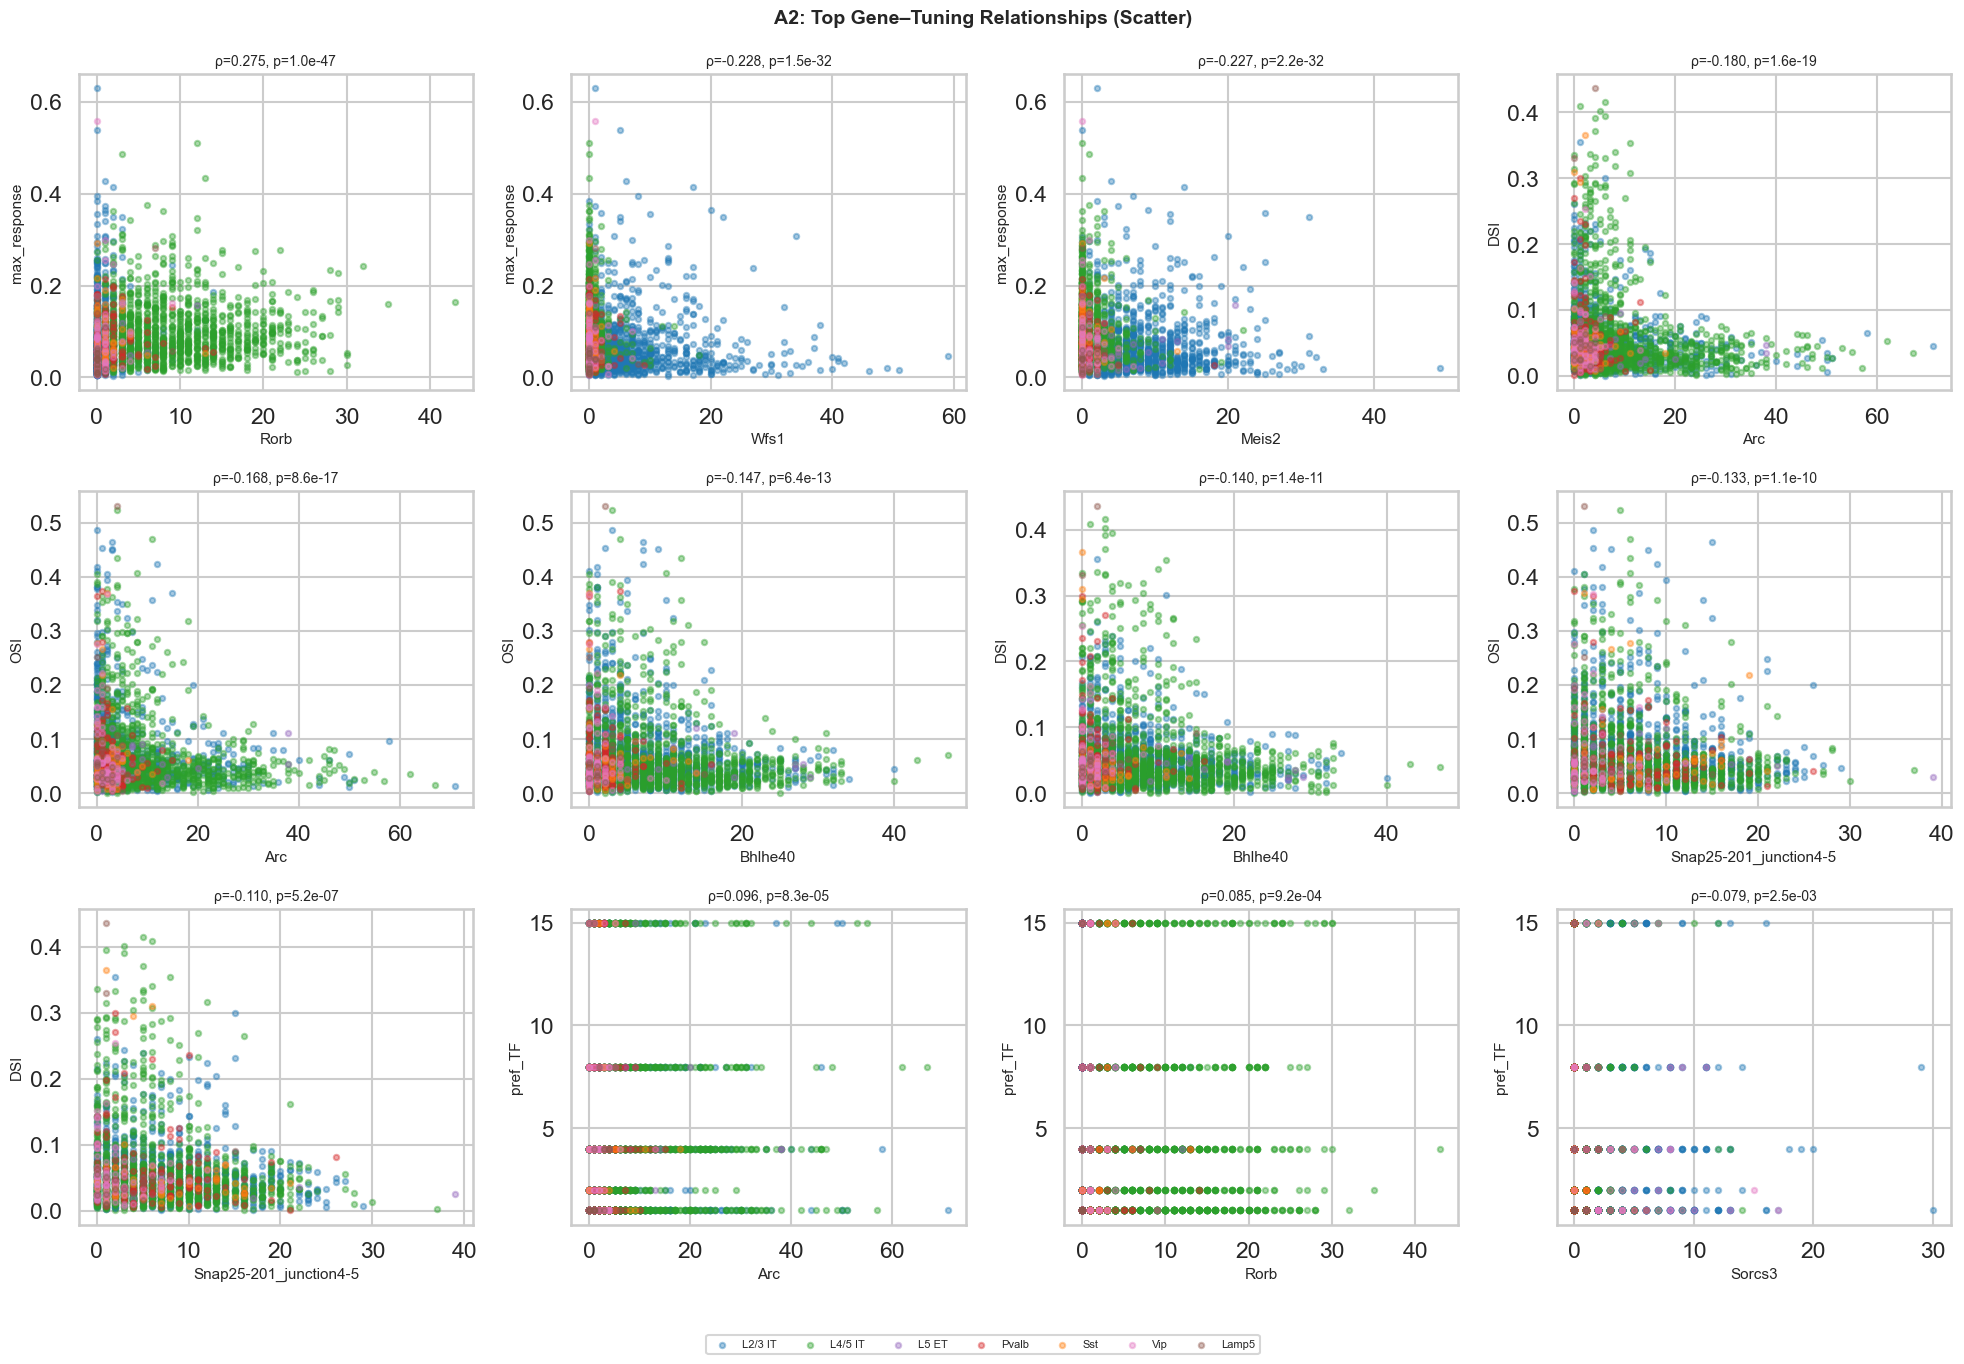

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# A2.4  Scatter plots for top gene–tuning relationships
# ══════════════════════════════════════════════════════════════════════

# Pick top 3 significant genes per metric (by absolute rho)
top_pairs = (corr_df[corr_df['sig']]
             .assign(abs_rho=lambda x: x['rho'].abs())
             .sort_values('abs_rho', ascending=False)
             .groupby('metric').head(3)
             .reset_index(drop=True))

n_pairs_plot = len(top_pairs)
if n_pairs_plot > 0:
    ncols = min(4, n_pairs_plot)
    nrows = int(np.ceil(n_pairs_plot / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.atleast_1d(axes).flat

    for ax, (_, row) in zip(axes, top_pairs.iterrows()):
        gene, met = row['gene'], row['metric']
        gi = GENE_COLS.index(gene)
        gx = gene_expr[:, gi]
        y = tuning_df[met].values
        valid = ~np.isnan(y) & ~np.isnan(gx)
        sc_labels = obs['subclass_name'].values

        for sc in present_subclasses:
            m = valid & (sc_labels == sc)
            ax.scatter(gx[m], y[m], alpha=0.4, s=15, color=SUBCLASS_COLORS[sc],
                       label=SUBCLASS_SHORT[sc])
        ax.set_xlabel(gene, fontsize=11)
        ax.set_ylabel(met, fontsize=11)
        ax.set_title(f"ρ={row['rho']:.3f}, p={row['p_adj']:.1e}", fontsize=10)

    # Remove unused axes
    for ax in axes:
        if not ax.has_data():
            ax.set_visible(False)

    # Single legend outside
    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(present_subclasses),
               fontsize=8, bbox_to_anchor=(0.5, -0.02))
    plt.suptitle('A2: Top Gene–Tuning Relationships (Scatter)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()
else:
    print("No significant gene–tuning pairs found.")